In [84]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [85]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (42000, 785)
Test shape: (28000, 784)


In [86]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


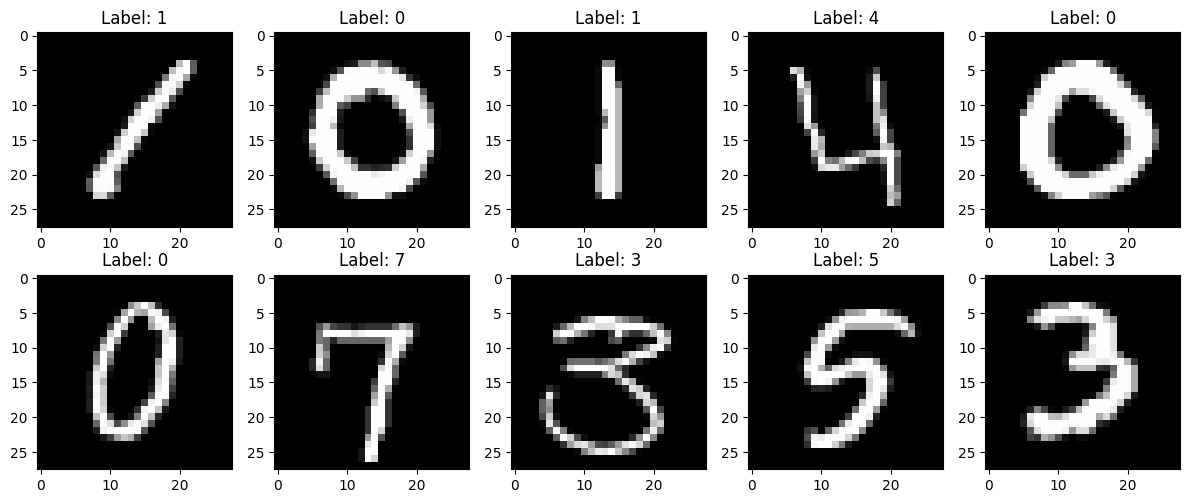

In [87]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))

for i, ax in enumerate(axes.flat):
    pixels = train.iloc[i, 1:].values.reshape(28,28)
    ax.imshow(pixels, cmap="gray")
    ax.set_title(f"Label: {train.iloc[i, 0]}")
    
plt.tight_layout()
plt.show()

In [91]:
X = train.drop("label", axis=1).values
y = train["label"].values

X = X / 255.0
test_data = test.values / 255.0

# Split into train and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (33600, 784)
X_val shape: (8400, 784)


In [101]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
val_preds = rf.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_preds))

Validation Accuracy: 0.9629761904761904


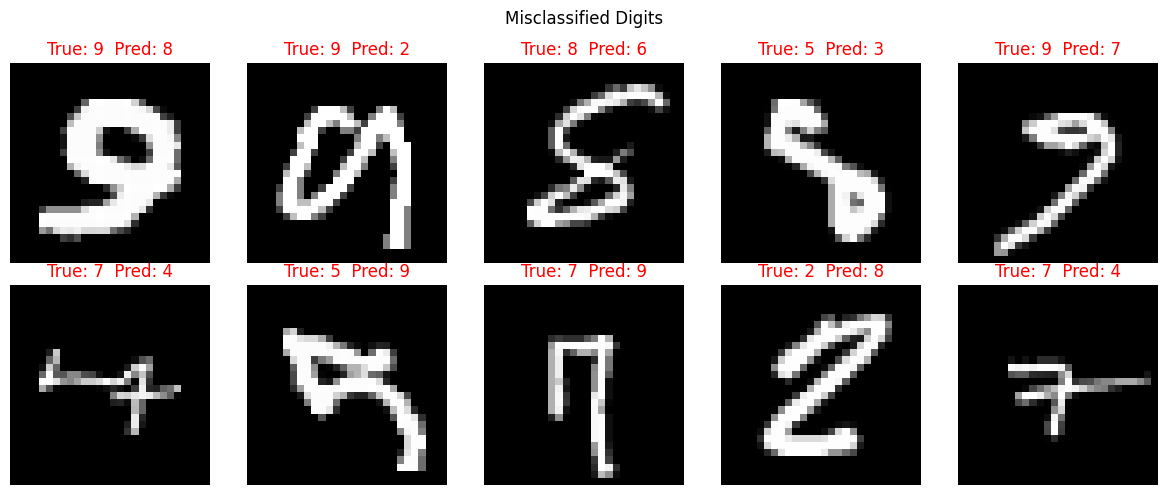

In [102]:
wrong_idx = np.where(val_preds != y_val)[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = wrong_idx[i]
    pixels = X_val[idx].reshape(28, 28)
    ax.imshow(pixels, cmap="gray")
    ax.set_title(f"True: {y_val[idx]}  Pred: {val_preds[idx]}", color="red")
    ax.axis("off")

plt.suptitle("Misclassified Digits")
plt.tight_layout()
plt.show()

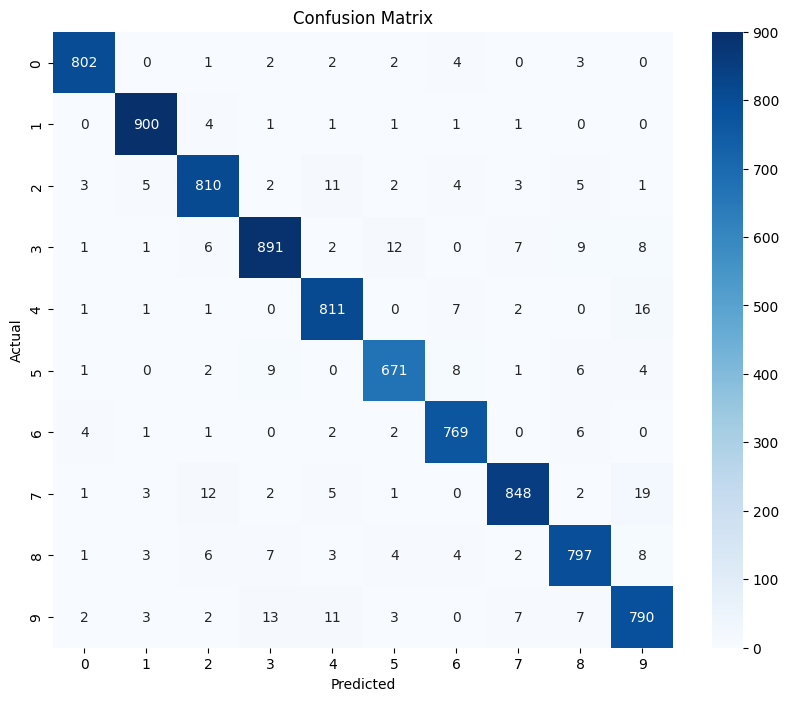

In [103]:
cm = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()